## Import Lib + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


## Data Cleaning

In [3]:
print(f"duplicate ID values: {df['ID'].duplicated().sum()}")
df = df.drop(columns=["ID"])
print(f"shape after dropping ID: {df.shape}")

duplicate ID values: 0
shape after dropping ID: (2240, 28)


In [4]:
print(f"Z_CostContact unique values: {df['Z_CostContact'].unique()}")
print(f"Z_Revenue unique values: {df['Z_Revenue'].unique()}")
# Both columns take exactly one value across all rows — zero variance, no predictive content.
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])
print(f"shape after dropping constant columns: {df.shape}")

Z_CostContact unique values: [3]
Z_Revenue unique values: [11]
shape after dropping constant columns: (2240, 26)


In [5]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
print(f"Dt_Customer range: {df['Dt_Customer'].min().date()} to {df['Dt_Customer'].max().date()}")

# Customer_Tenure_Days: days enrolled as of the dataset's last enrollment date — a simple, easy-to-justify
# derived feature in place of the raw date string, same "derived, not raw" pattern used for Installs/Size/Price
# in google_play_data.
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df["Customer_Tenure_Days"].describe()

Dt_Customer range: 2012-07-30 to 2014-06-29


count    2240.000000
mean      353.582143
std       202.122512
min         0.000000
25%       180.750000
50%       355.500000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64

In [6]:
reference_year = df["Dt_Customer"].dt.year.max()
df["Age"] = reference_year - df["Year_Birth"]
print(df["Age"].describe())

# Three rows carry an implausible Year_Birth (1893, 1899, 1900 -> age 121, 115, 114) — genuine data-entry
# errors, not a real elderly-customer segment. Small n, dropped outright rather than capped/imputed.
age_outliers = df[df["Age"] > 100]
print(f"\nage outlier rows ({len(age_outliers)}):")
print(age_outliers[["Year_Birth", "Age"]])

df = df[df["Age"] <= 100].reset_index(drop=True)
print(f"\nshape after dropping age outliers: {df.shape}")

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64

age outlier rows (3):
     Year_Birth  Age
192        1900  114
239        1893  121
339        1899  115

shape after dropping age outliers: (2237, 28)


In [7]:
print("Marital_Status before:")
print(df["Marital_Status"].value_counts())

# "Absurd" (2 rows) and "YOLO" (2 rows) are joke entries, not real categories. "Alone" (3 rows) is a
# genuine status but semantically identical to "Single" and too small to model as its own category —
# folded in alongside the joke labels rather than kept as a 3-row category or a vague "Other" bucket.
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})

print("\nMarital_Status after:")
print(df["Marital_Status"].value_counts())

Marital_Status before:
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status after:
Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [9]:
missing_income = df['Income'].isna().sum()
print(f"rows with missing Income (target): {missing_income}")
df = df.dropna(subset=["Income"]).reset_index(drop=True)
print(f"shape after dropping rows with missing Income: {df.shape}")
# Response is still present here (unaffected by the Income drop) purely to support the "Income vs
# Response" deep dive below — it is not a regression feature.

rows with missing Income (target): 24
shape after dropping rows with missing Income: (2213, 28)


## EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2213 entries, 0 to 2212
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year_Birth            2213 non-null   int64         
 1   Education             2213 non-null   object        
 2   Marital_Status        2213 non-null   object        
 3   Income                2213 non-null   float64       
 4   Kidhome               2213 non-null   int64         
 5   Teenhome              2213 non-null   int64         
 6   Dt_Customer           2213 non-null   datetime64[ns]
 7   Recency               2213 non-null   int64         
 8   MntWines              2213 non-null   int64         
 9   MntFruits             2213 non-null   int64         
 10  MntMeatProducts       2213 non-null   int64         
 11  MntFishProducts       2213 non-null   int64         
 12  MntSweetProducts      2213 non-null   int64         
 13  MntGoldProds      

In [11]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure_Days,Age
count,2213.000000,2213.000000,2213.000000,2213.000000,2213,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,...,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000,2213.000000
mean,1968.917307,52236.581563,0.441934,0.505648,2013-07-10 06:26:30.962494464,49.007682,305.153638,26.323995,166.962494,37.635337,...,5.321735,0.073656,0.074108,0.072752,0.064166,0.013556,0.009038,0.150474,353.731586,45.082693
min,1940.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
25%,1959.000000,35246.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,37.000000
50%,1970.000000,51373.000000,0.000000,0.000000,2013-07-08 00:00:00,49.000000,175.000000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,356.000000,44.000000
75%,1977.000000,68487.000000,1.000000,1.000000,2013-12-31 00:00:00,74.000000,505.000000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,529.000000,55.000000
max,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,699.000000,74.000000
std,11.700216,25178.603047,0.536965,0.544236,NaN,28.941864,337.305490,39.735932,224.226178,54.763278,...,2.425092,0.261269,0.262005,0.259788,0.245104,0.115666,0.094657,0.357617,202.450745,11.700216


## Distribution Check

In [12]:
sns.set_theme(style="whitegrid")

def plot_numeric_distribution(df, col, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} — histogram")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} — boxplot")
    plt.tight_layout()
    plt.show()
    print(df[col].describe())

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[col][(df[col] < lower) | (df[col] > upper)]
    print(f"IQR outlier bounds (1.5x rule): [{lower:.2f}, {upper:.2f}]")
    print(f"outliers: {len(outliers)} rows ({len(outliers) / df[col].notna().sum():.2%} of non-missing data)")
    if len(outliers):
        print(f"  below lower bound: {(outliers < lower).sum()}, above upper bound: {(outliers > upper).sum()}")

def plot_categorical_distribution(df, col, order=None, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    order = order or df[col].value_counts().index
    ax = sns.countplot(x=df[col], order=order)
    ax.set_title(f"{col} — value counts")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(normalize=True).round(3))

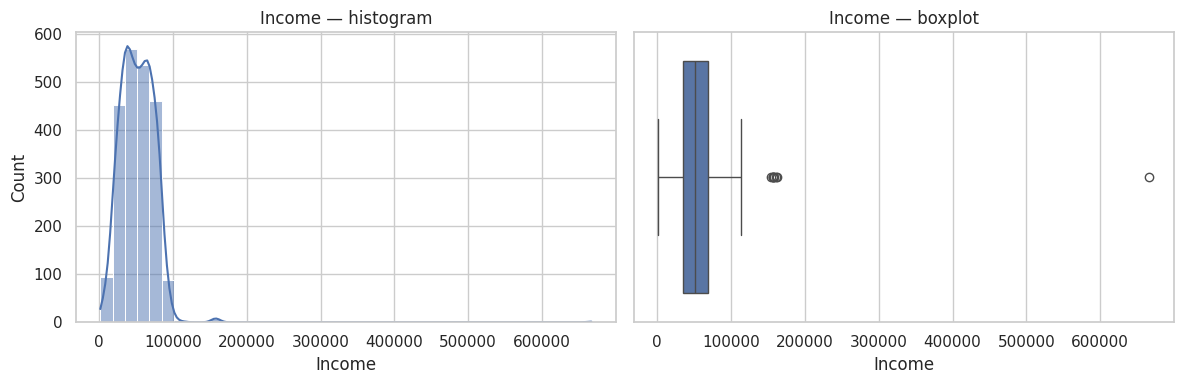

count      2213.000000
mean      52236.581563
std       25178.603047
min        1730.000000
25%       35246.000000
50%       51373.000000
75%       68487.000000
max      666666.000000
Name: Income, dtype: float64
IQR outlier bounds (1.5x rule): [-14615.50, 118348.50]
outliers: 8 rows (0.36% of non-missing data)
  below lower bound: 0, above upper bound: 8


In [13]:
# Income has no missing values in this notebook — rows with missing Income were dropped in Data Cleaning.
plot_numeric_distribution(df, "Income")

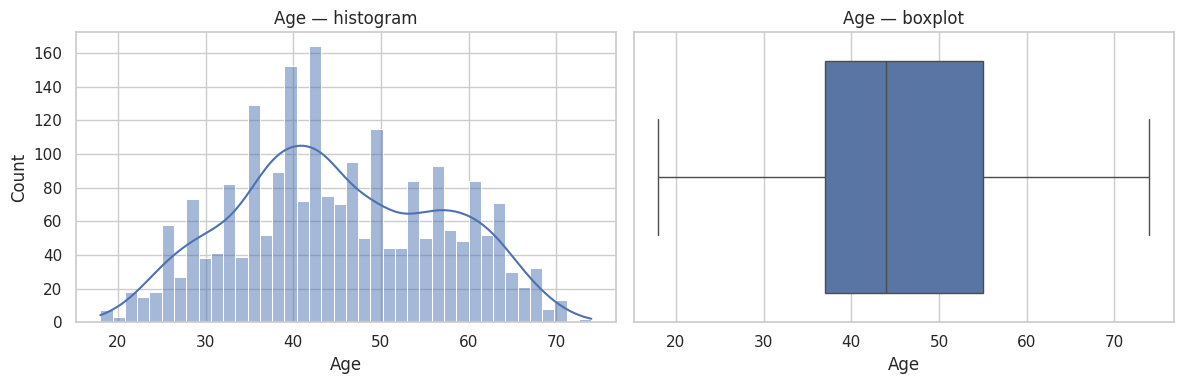

count    2213.000000
mean       45.082693
std        11.700216
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64
IQR outlier bounds (1.5x rule): [10.00, 82.00]
outliers: 0 rows (0.00% of non-missing data)


In [14]:
plot_numeric_distribution(df, "Age")

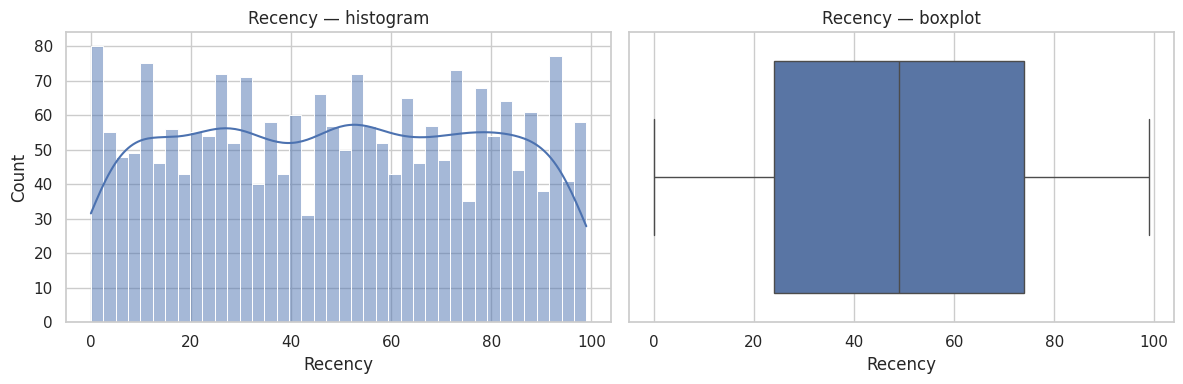

count    2213.000000
mean       49.007682
std        28.941864
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64
IQR outlier bounds (1.5x rule): [-51.00, 149.00]
outliers: 0 rows (0.00% of non-missing data)


In [15]:
plot_numeric_distribution(df, "Recency")

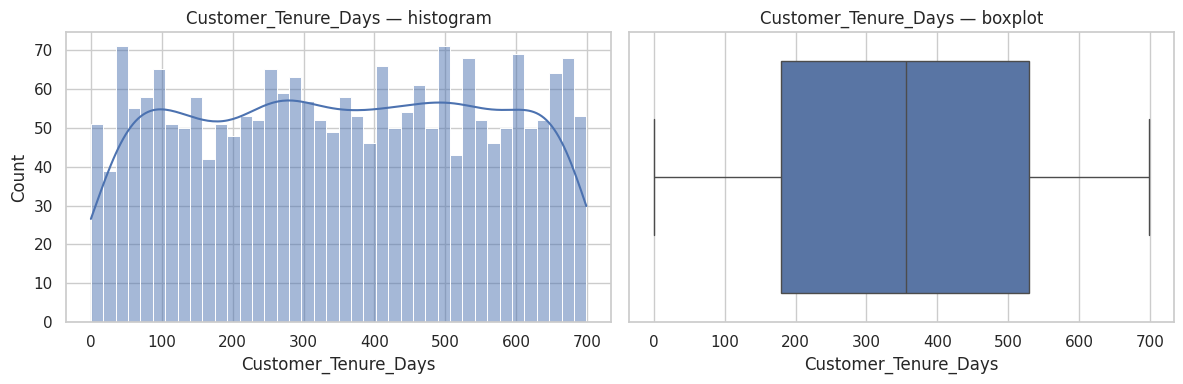

count    2213.000000
mean      353.731586
std       202.450745
min         0.000000
25%       180.000000
50%       356.000000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64
IQR outlier bounds (1.5x rule): [-343.50, 1052.50]
outliers: 0 rows (0.00% of non-missing data)


In [16]:
plot_numeric_distribution(df, "Customer_Tenure_Days")

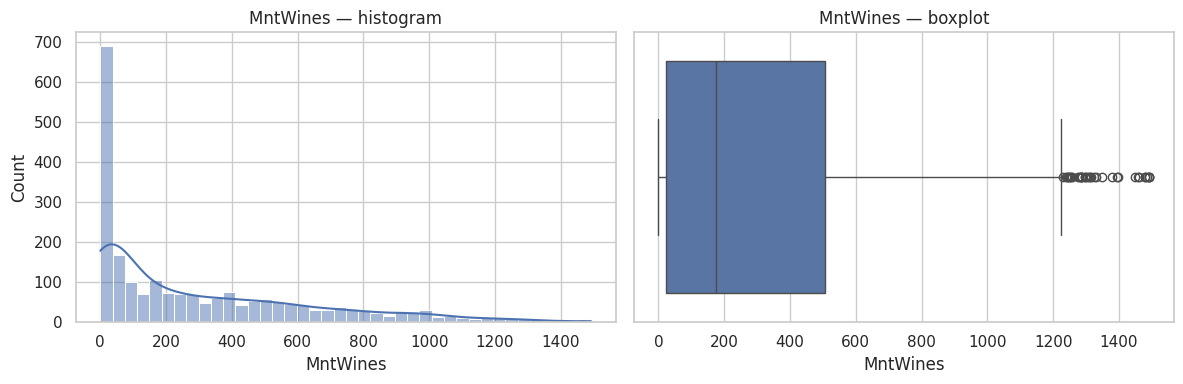

count    2213.000000
mean      305.153638
std       337.305490
min         0.000000
25%        24.000000
50%       175.000000
75%       505.000000
max      1493.000000
Name: MntWines, dtype: float64
IQR outlier bounds (1.5x rule): [-697.50, 1226.50]
outliers: 35 rows (1.58% of non-missing data)
  below lower bound: 0, above upper bound: 35


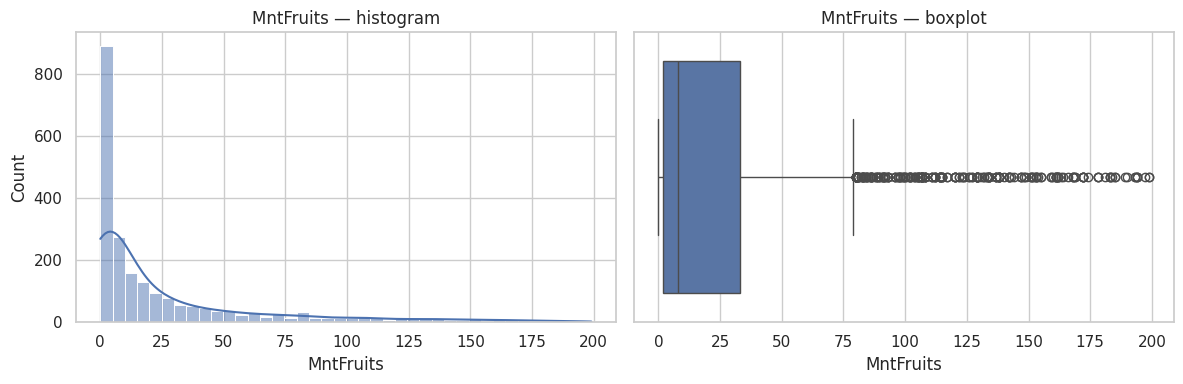

count    2213.000000
mean       26.323995
std        39.735932
min         0.000000
25%         2.000000
50%         8.000000
75%        33.000000
max       199.000000
Name: MntFruits, dtype: float64
IQR outlier bounds (1.5x rule): [-44.50, 79.50]
outliers: 245 rows (11.07% of non-missing data)
  below lower bound: 0, above upper bound: 245


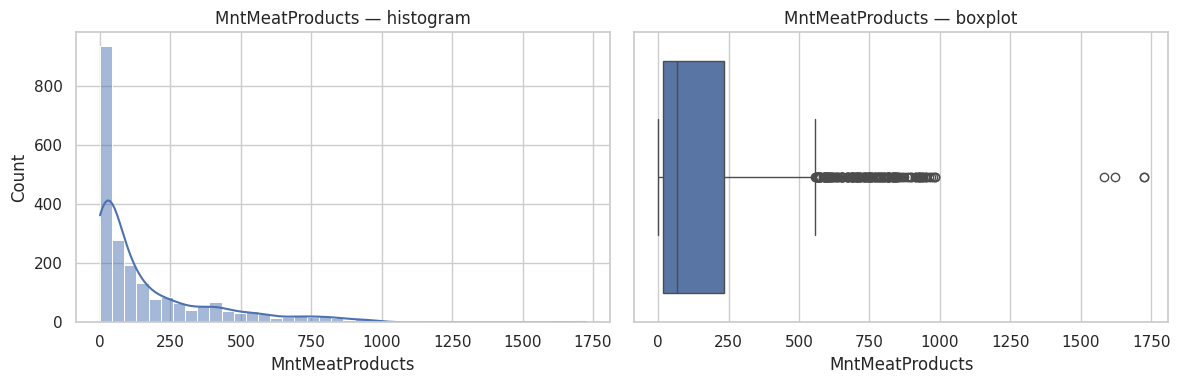

count    2213.000000
mean      166.962494
std       224.226178
min         0.000000
25%        16.000000
50%        68.000000
75%       232.000000
max      1725.000000
Name: MntMeatProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-308.00, 556.00]
outliers: 173 rows (7.82% of non-missing data)
  below lower bound: 0, above upper bound: 173


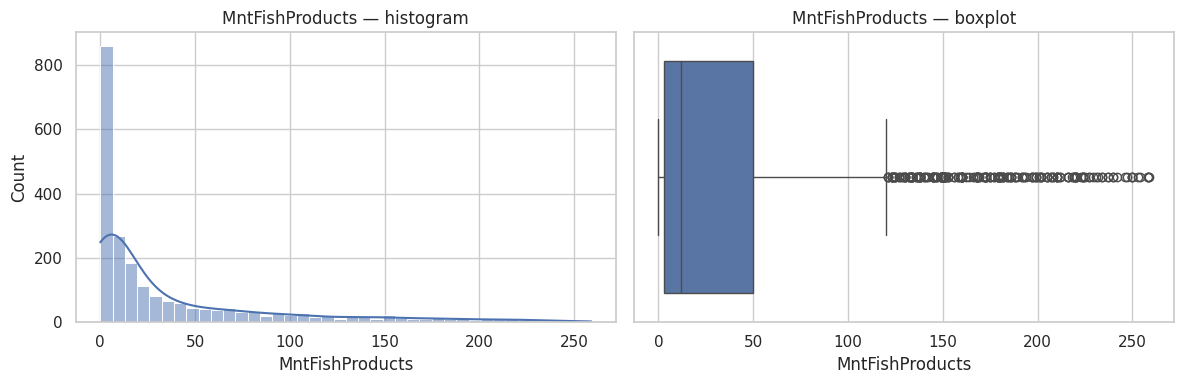

count    2213.000000
mean       37.635337
std        54.763278
min         0.000000
25%         3.000000
50%        12.000000
75%        50.000000
max       259.000000
Name: MntFishProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-67.50, 120.50]
outliers: 222 rows (10.03% of non-missing data)
  below lower bound: 0, above upper bound: 222


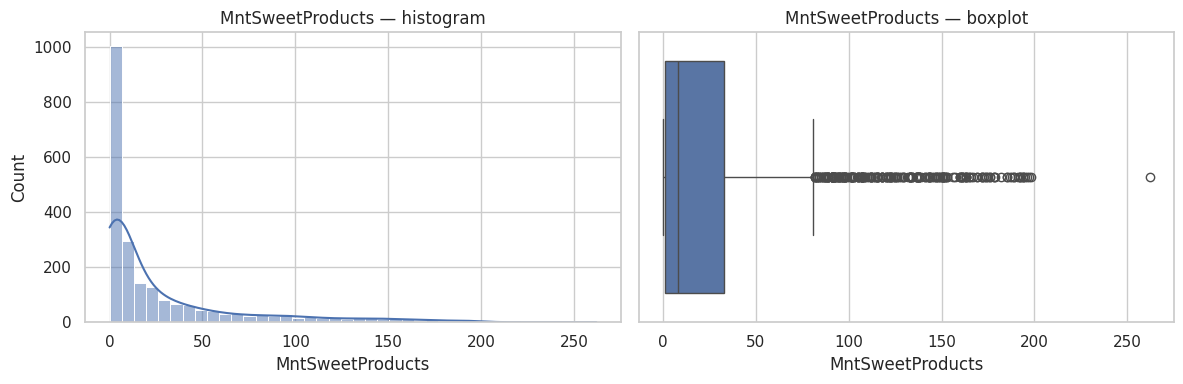

count    2213.000000
mean       27.034794
std        41.085433
min         0.000000
25%         1.000000
50%         8.000000
75%        33.000000
max       262.000000
Name: MntSweetProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-47.00, 81.00]
outliers: 246 rows (11.12% of non-missing data)
  below lower bound: 0, above upper bound: 246


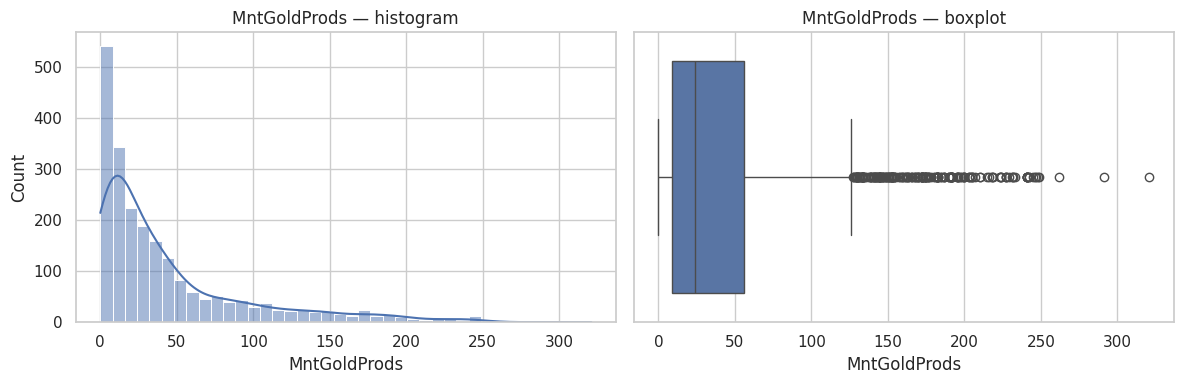

count    2213.000000
mean       43.911432
std        51.699746
min         0.000000
25%         9.000000
50%        24.000000
75%        56.000000
max       321.000000
Name: MntGoldProds, dtype: float64
IQR outlier bounds (1.5x rule): [-61.50, 126.50]
outliers: 204 rows (9.22% of non-missing data)
  below lower bound: 0, above upper bound: 204


In [17]:
# Product spend columns (Products group)
for col in ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    plot_numeric_distribution(df, col)

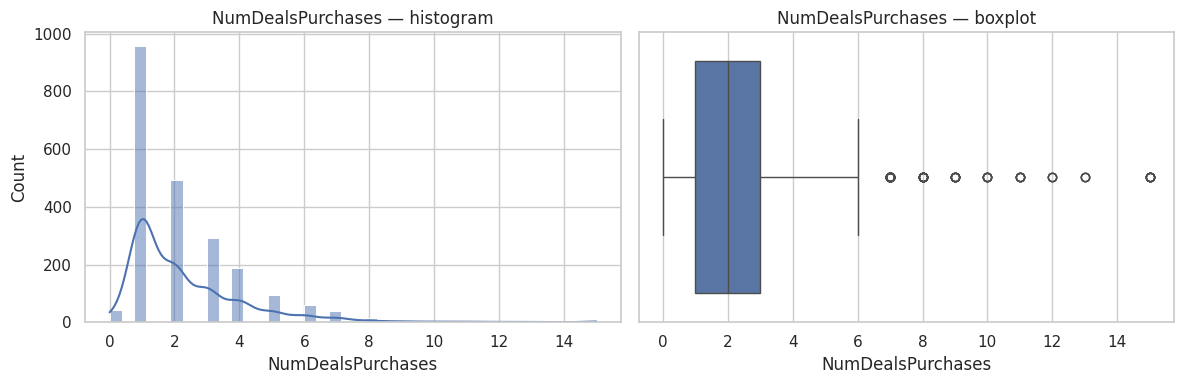

count    2213.000000
mean        2.325350
std         1.924402
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: NumDealsPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-2.00, 6.00]
outliers: 84 rows (3.80% of non-missing data)
  below lower bound: 0, above upper bound: 84


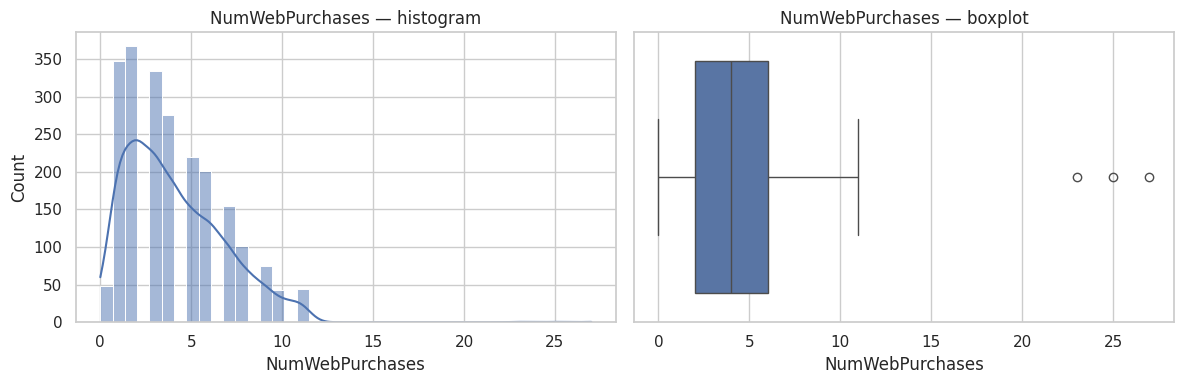

count    2213.000000
mean        4.087664
std         2.741664
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        27.000000
Name: NumWebPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-4.00, 12.00]
outliers: 3 rows (0.14% of non-missing data)
  below lower bound: 0, above upper bound: 3


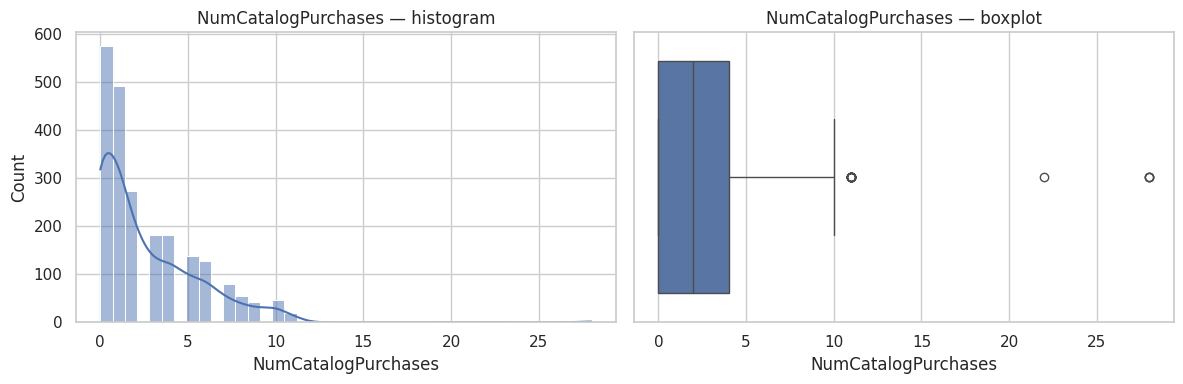

count    2213.000000
mean        2.671487
std         2.927096
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        28.000000
Name: NumCatalogPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-6.00, 10.00]
outliers: 23 rows (1.04% of non-missing data)
  below lower bound: 0, above upper bound: 23


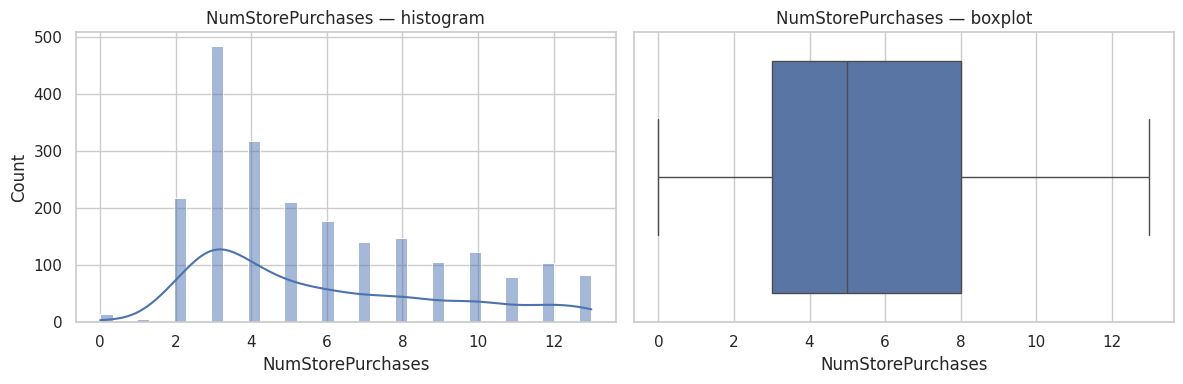

count    2213.000000
mean        5.805242
std         3.250752
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        13.000000
Name: NumStorePurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-4.50, 15.50]
outliers: 0 rows (0.00% of non-missing data)


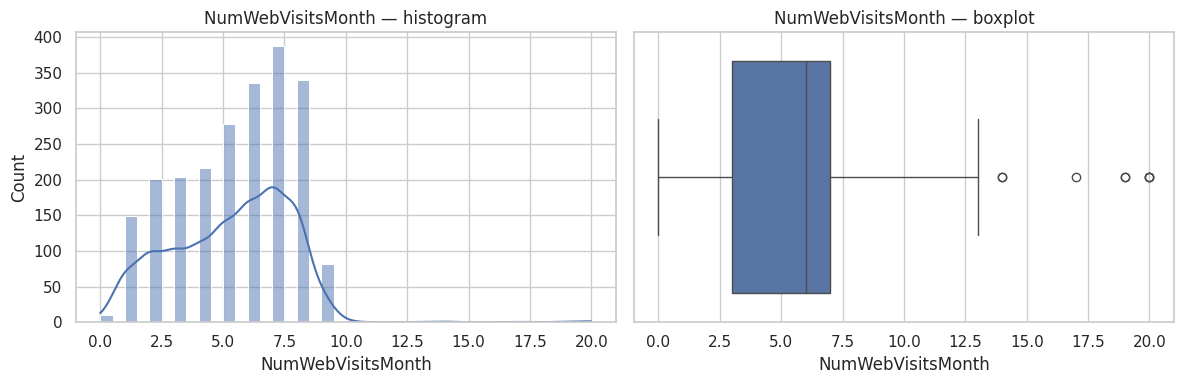

count    2213.000000
mean        5.321735
std         2.425092
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        20.000000
Name: NumWebVisitsMonth, dtype: float64
IQR outlier bounds (1.5x rule): [-3.00, 13.00]
outliers: 8 rows (0.36% of non-missing data)
  below lower bound: 0, above upper bound: 8


In [18]:
# Purchase-channel + engagement columns (Place group)
for col in ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']:
    plot_numeric_distribution(df, col)

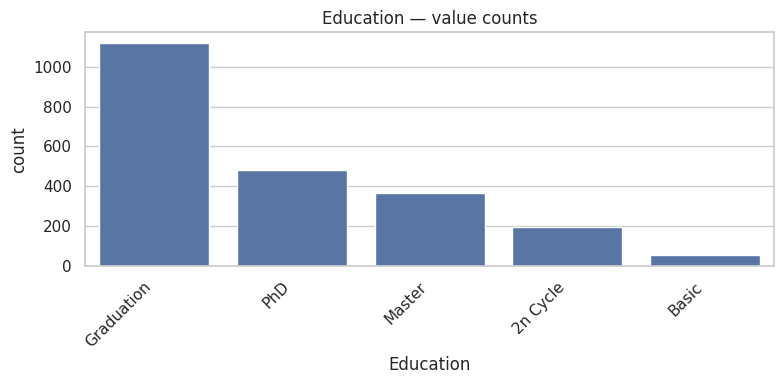

Education
Graduation    0.504
PhD           0.217
Master        0.165
2n Cycle      0.089
Basic         0.024
Name: proportion, dtype: float64


In [19]:
plot_categorical_distribution(df, "Education")

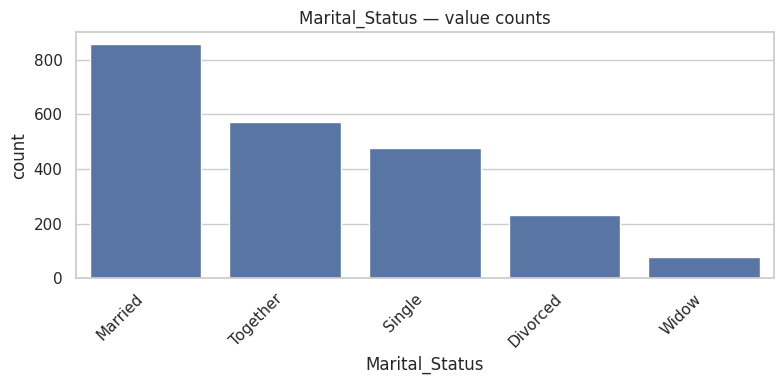

Marital_Status
Married     0.387
Together    0.258
Single      0.216
Divorced    0.104
Widow       0.034
Name: proportion, dtype: float64


In [20]:
plot_categorical_distribution(df, "Marital_Status")

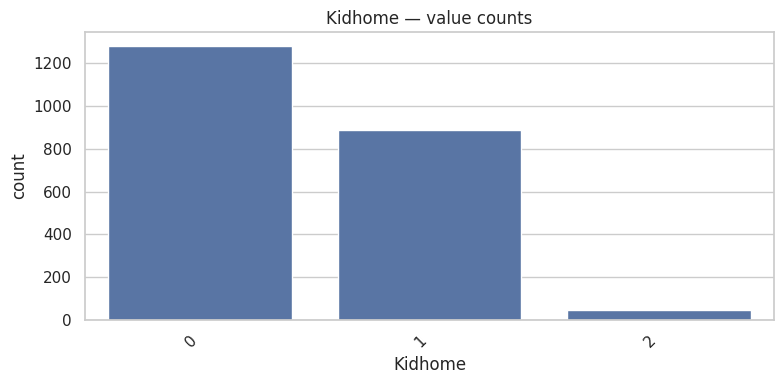

Kidhome
0    0.579
1    0.400
2    0.021
Name: proportion, dtype: float64


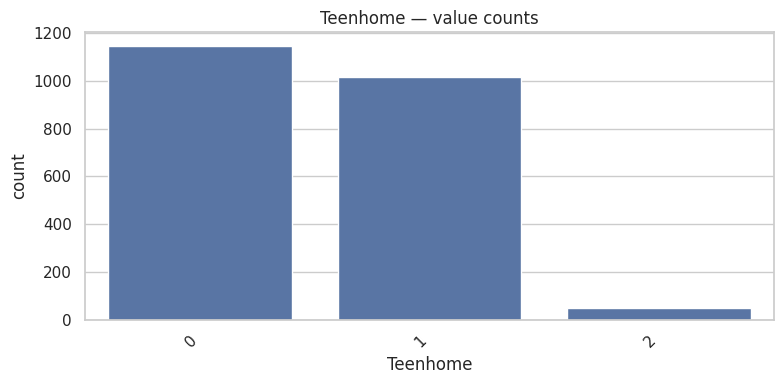

Teenhome
0    0.517
1    0.460
2    0.023
Name: proportion, dtype: float64


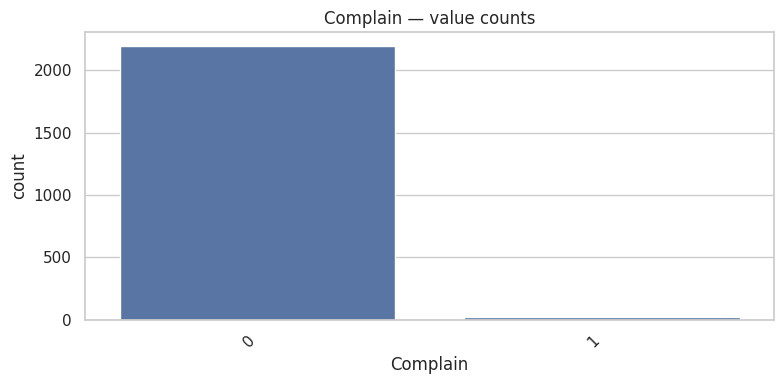

Complain
0    0.991
1    0.009
Name: proportion, dtype: float64


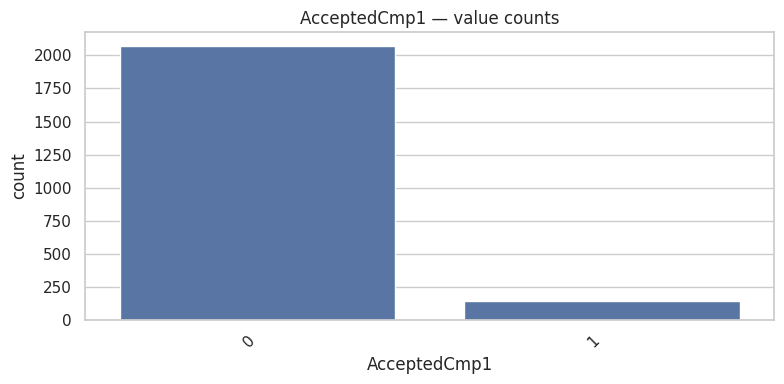

AcceptedCmp1
0    0.936
1    0.064
Name: proportion, dtype: float64


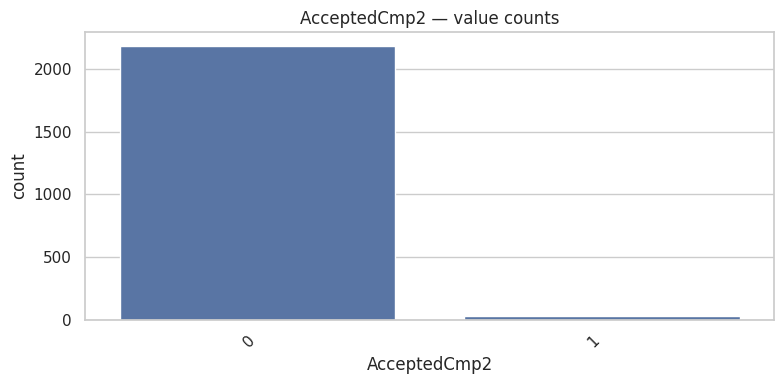

AcceptedCmp2
0    0.986
1    0.014
Name: proportion, dtype: float64


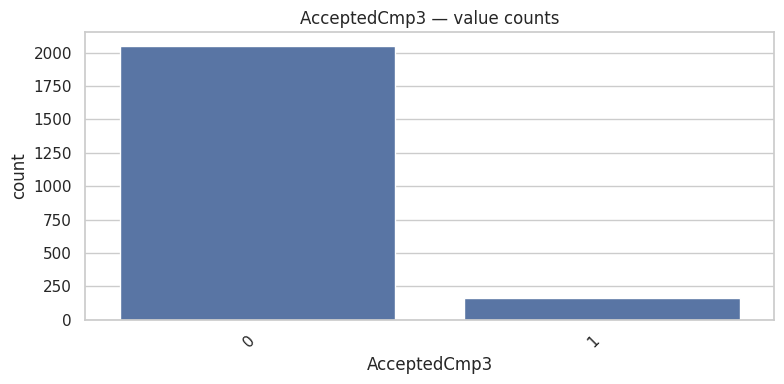

AcceptedCmp3
0    0.926
1    0.074
Name: proportion, dtype: float64


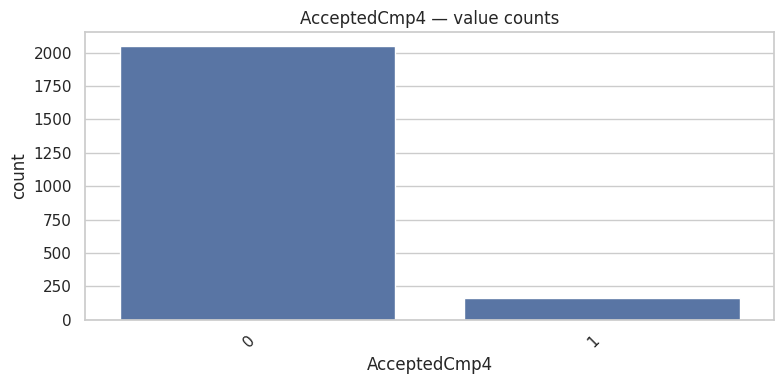

AcceptedCmp4
0    0.926
1    0.074
Name: proportion, dtype: float64


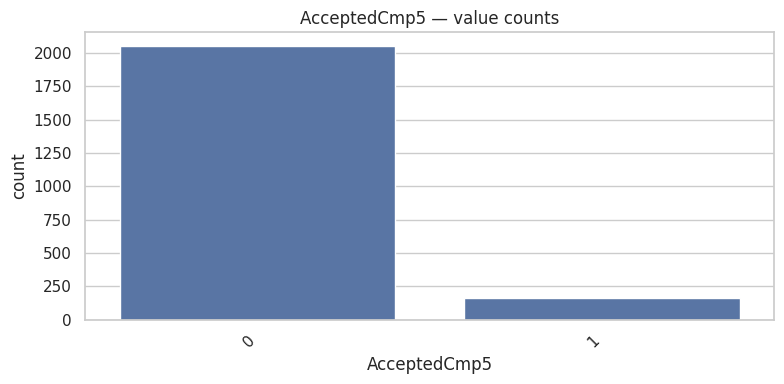

AcceptedCmp5
0    0.927
1    0.073
Name: proportion, dtype: float64


In [21]:
# Binary flags: household composition, complaints, prior-campaign acceptance (Promotion group)
for col in ['Kidhome', 'Teenhome', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']:
    plot_categorical_distribution(df, col)

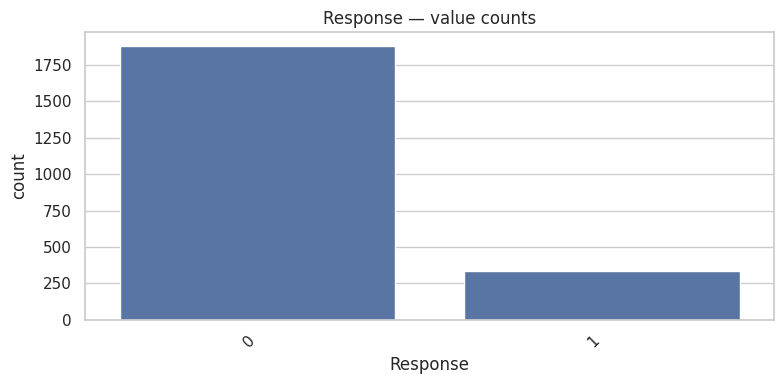

Response
0    0.85
1    0.15
Name: proportion, dtype: float64
class balance — Response (accepted last campaign): 15.0%


In [22]:
plot_categorical_distribution(df, "Response")
resp_rate = df['Response'].mean()
print(f"class balance — Response (accepted last campaign): {resp_rate:.1%}")

## Regression EDA — Primary Target: Income

In [23]:
numeric_cols = ['Age', 'Recency', 'Kidhome', 'Teenhome', 'Customer_Tenure_Days', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
categorical_cols = ['Education', 'Marital_Status']
# Income excluded from its own feature list, obviously. AcceptedCmp1-5 included but flagged (leakage-
# adjacent, see the classify track); Response excluded here and explored separately in the deep dive below
# (mirrors google_play_data/regression.ipynb keeping hit out of the main ranking).

def correlation_ratio(categories, values):
    d = pd.DataFrame({"cat": categories.values, "val": values.values}).dropna()
    grand_mean = d["val"].mean()
    group_stats = d.groupby("cat")["val"].agg(["mean", "count"])
    ss_between = (group_stats["count"] * (group_stats["mean"] - grand_mean) ** 2).sum()
    ss_total = ((d["val"] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total)

relevance_reg = {}
for col in numeric_cols:
    relevance_reg[col] = abs(df[col].corr(df["Income"]))
for col in categorical_cols:
    relevance_reg[col] = correlation_ratio(df[col], df["Income"])

relevance_reg = pd.Series(relevance_reg).sort_values(ascending=False)
relevance_reg_df = relevance_reg.rename("relevance_score").to_frame()
relevance_reg_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in relevance_reg_df.index]
relevance_reg_df

,relevance_score,type
NumCatalogPurchases,0.589090,numeric
MntMeatProducts,0.584361,numeric
MntWines,0.578481,numeric
NumWebVisitsMonth,0.552736,numeric
NumStorePurchases,0.530120,numeric
MntSweetProducts,0.440532,numeric
MntFishProducts,0.438523,numeric
MntFruits,0.430248,numeric
Kidhome,0.428231,numeric
NumWebPurchases,0.388183,numeric


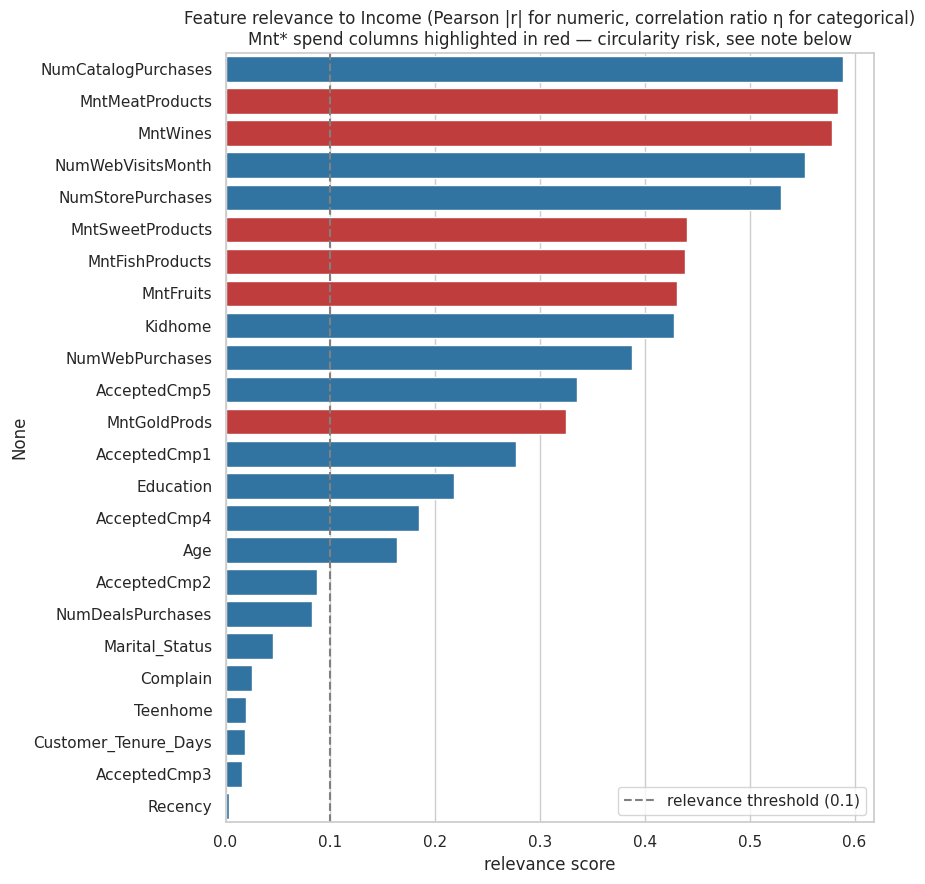

features clearing relevance threshold (0.1): ['NumCatalogPurchases', 'MntMeatProducts', 'MntWines', 'NumWebVisitsMonth', 'NumStorePurchases', 'MntSweetProducts', 'MntFishProducts', 'MntFruits', 'Kidhome', 'NumWebPurchases', 'AcceptedCmp5', 'MntGoldProds', 'AcceptedCmp1', 'Education', 'AcceptedCmp4', 'Age']


In [24]:
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
plt.figure(figsize=(9, 9))
colors = ["#d62728" if c in mnt_cols else "#1f77b4" for c in relevance_reg.index]
sns.barplot(x=relevance_reg.values, y=relevance_reg.index, hue=relevance_reg.index, palette=colors, legend=False)
plt.axvline(0.1, color="gray", linestyle="--", label="relevance threshold (0.1)")
plt.title("Feature relevance to Income (Pearson |r| for numeric, correlation ratio η for categorical)\nMnt* spend columns highlighted in red — circularity risk, see note below")
plt.xlabel("relevance score")
plt.legend()
plt.tight_layout()
plt.show()

RELEVANCE_THRESHOLD = 0.1
top_features_reg = relevance_reg[relevance_reg >= RELEVANCE_THRESHOLD].index.tolist()
print(f"features clearing relevance threshold ({RELEVANCE_THRESHOLD}): {top_features_reg}")

In [25]:
print("circularity note: the Mnt* spend columns plausibly correlate with Income in both directions — "
      "higher income gives more spending capacity, but spend is also just a behavioral variable, not "
      "literally derived from Income the way hit was literally derived from Installs_num in "
      "google_play_data. Real correlation risk, not mechanical circularity — included as candidates, "
      "flagged rather than excluded.")
df[mnt_cols].corrwith(df["Income"]).sort_values(key=abs, ascending=False).round(3)

circularity note: the Mnt* spend columns plausibly correlate with Income in both directions — higher income gives more spending capacity, but spend is also just a behavioral variable, not literally derived from Income the way hit was literally derived from Installs_num in google_play_data. Real correlation risk, not mechanical circularity — included as candidates, flagged rather than excluded.


MntMeatProducts     0.584
MntWines            0.578
MntSweetProducts    0.441
MntFishProducts     0.439
MntFruits           0.430
MntGoldProds        0.325
dtype: float64

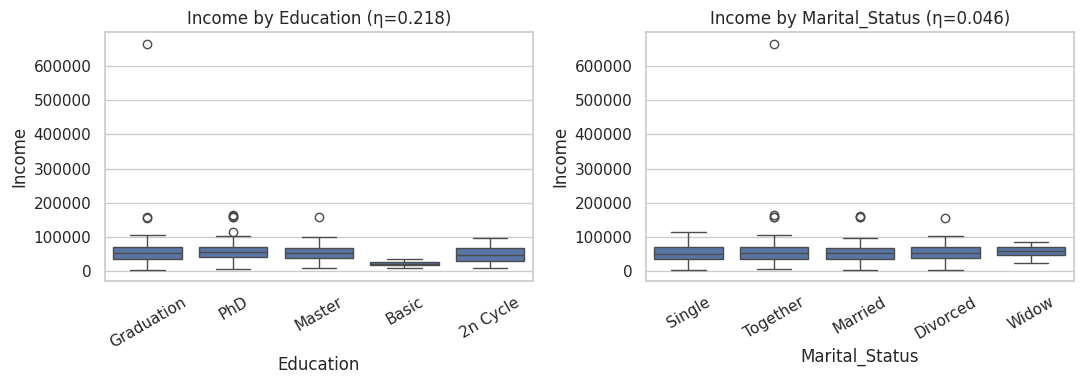

,mean,median,count
Education,,,
PhD,56088.258333,55185.0,480
Master,52917.534247,50943.0,365
Graduation,52720.373656,52028.5,1116
2n Cycle,47625.333333,46805.0,198
Basic,20306.259259,20744.0,54


In [26]:
eta_education = relevance_reg['Education']
eta_marital = relevance_reg['Marital_Status']
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df["Education"], y=df["Income"], ax=axes[0])
axes[0].set_title(f"Income by Education (η={eta_education:.3f})")
axes[0].tick_params(axis="x", rotation=30)
sns.boxplot(x=df["Marital_Status"], y=df["Income"], ax=axes[1])
axes[1].set_title(f"Income by Marital_Status (η={eta_marital:.3f})")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

df.groupby("Education")["Income"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)

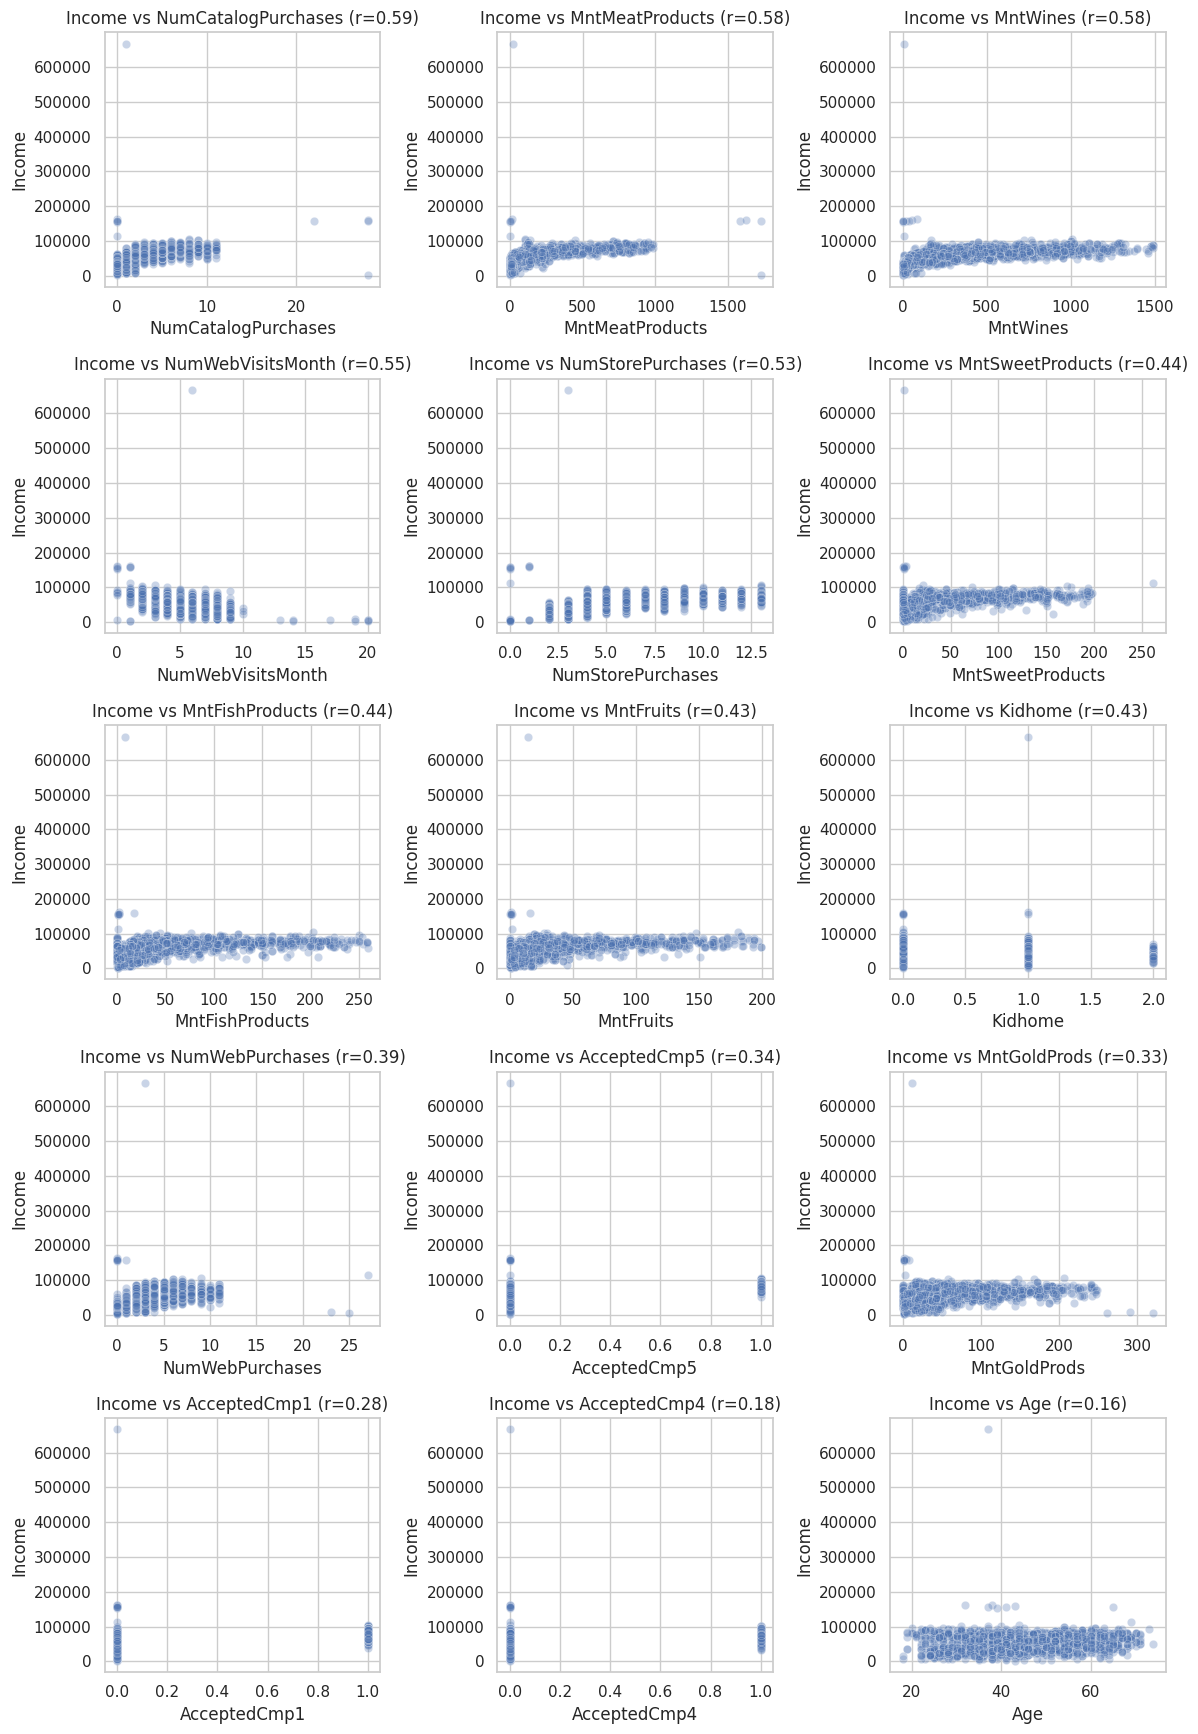

In [27]:
numeric_top = [c for c in top_features_reg if c in numeric_cols]
n = len(numeric_top)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
for ax, col in zip(axes.flat, numeric_top):
    sns.scatterplot(x=df[col], y=df["Income"], alpha=0.3, ax=ax)
    ax.set_title(f"Income vs {col} (r={relevance_reg[col]:.2f})")
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

### Discussion — Income

## Multicollinearity (numeric feature-to-feature)

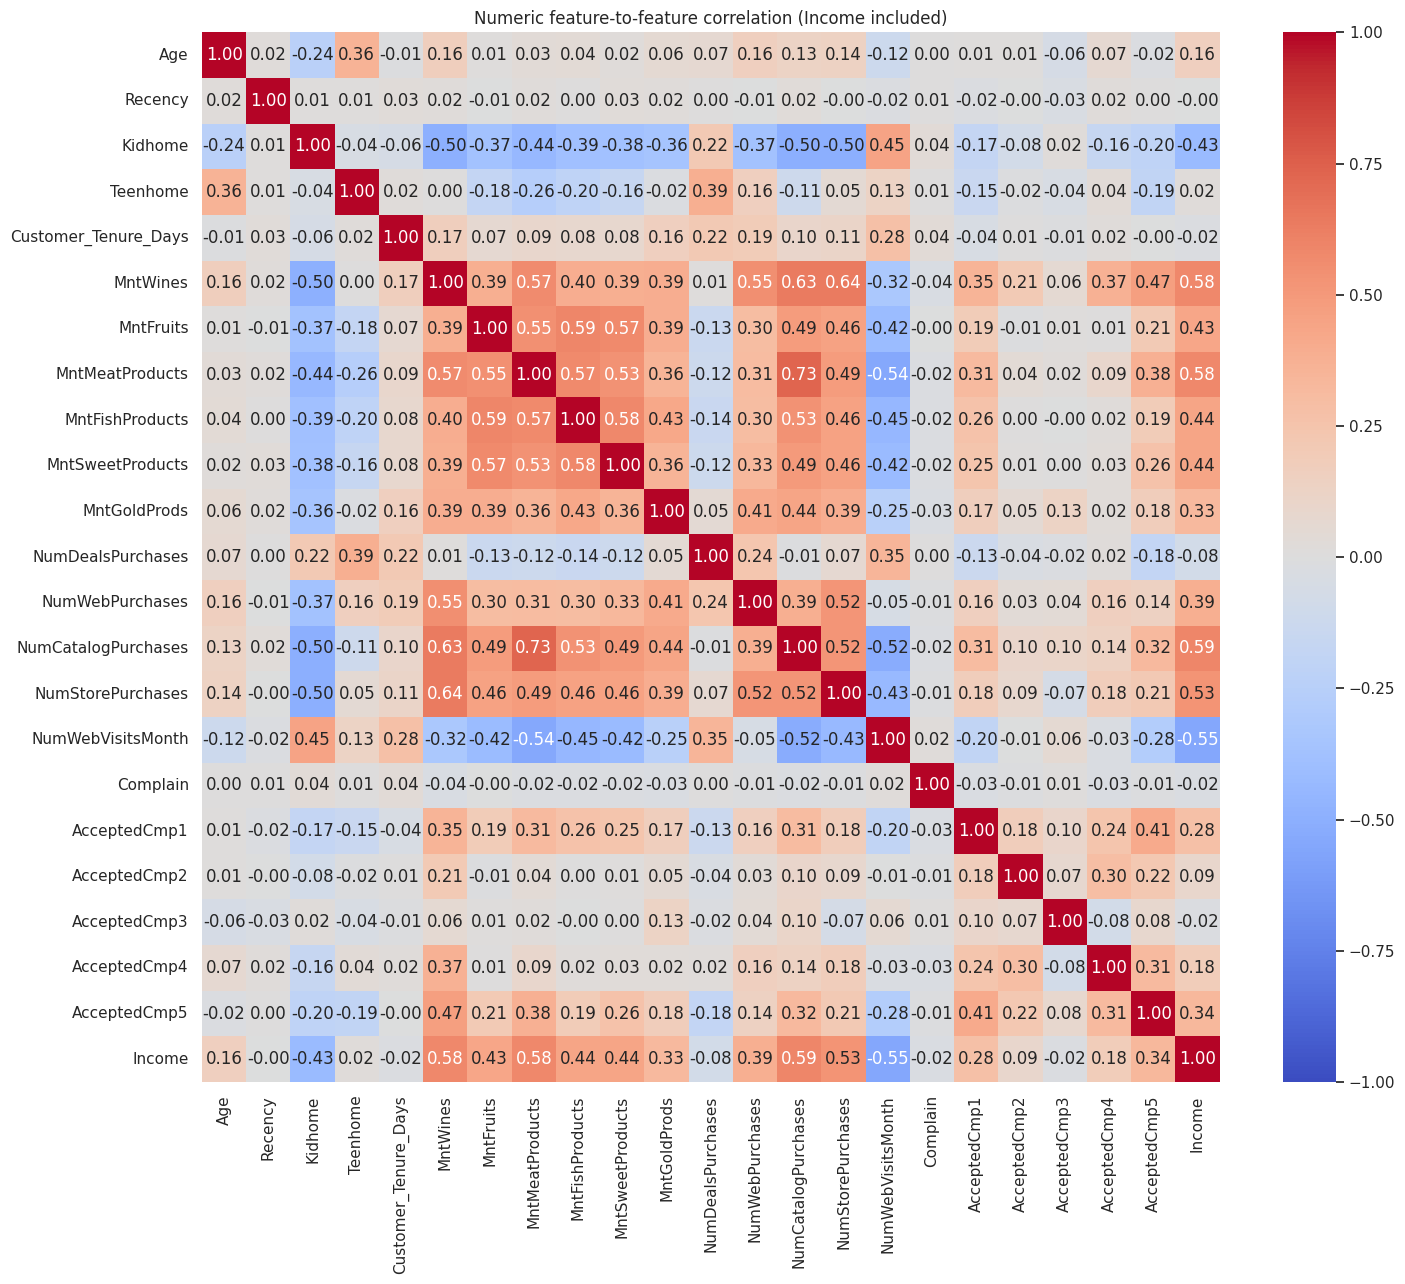

In [28]:
numeric_cols_full = numeric_cols + ["Income"]
corr_matrix = df[numeric_cols_full].corr()
plt.figure(figsize=(15, 13))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric feature-to-feature correlation (Income included)")
plt.tight_layout()
plt.show()

## Deep Dive — Income vs Response

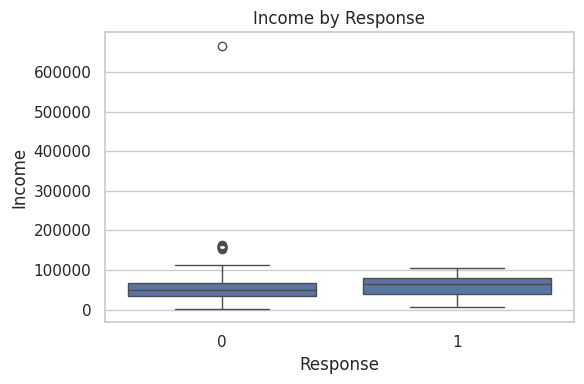

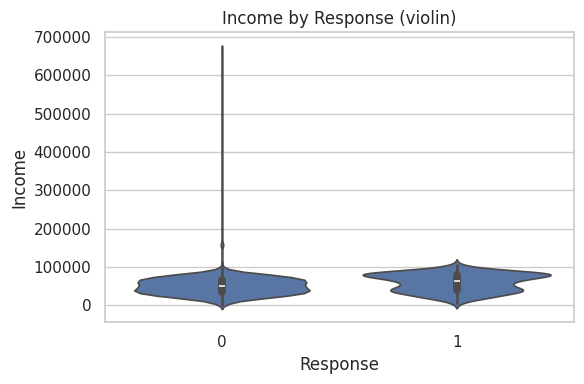

,median,mean,count
Response,,,
0,50150.0,50824.326064,1880
1,64090.0,60209.675676,333


In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Response"], y=df["Income"])
plt.title("Income by Response")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(x=df["Response"], y=df["Income"], ax=ax)
ax.set_title("Income by Response (violin)")
plt.tight_layout()
plt.show()

df.groupby("Response")["Income"].agg(["median", "mean", "count"])

## Categorical Redundancy (Education vs. Marital_Status)

In [30]:
def cramers_v(a, b):
    mask = a.notna() & b.notna()
    table = pd.crosstab(a[mask], b[mask])
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

# Same shared foundation check as classify.ipynb, duplicated so this notebook runs standalone.
edu_marital_v = cramers_v(df['Education'], df['Marital_Status'])
print(f"Cramér's V(Education, Marital_Status) = {edu_marital_v:.3f}")

Cramér's V(Education, Marital_Status) = 0.043


## Model-Based Feature Importance (RF)

In [31]:
def build_feature_matrix(df, num_cols, cat_cols):
    X_num = df[num_cols].copy()
    for c in num_cols:
        X_num[c] = X_num[c].fillna(X_num[c].median())
    frames = [X_num]
    col_to_parent = {c: c for c in num_cols}
    for col in cat_cols:
        dummies = pd.get_dummies(df[col].fillna("__missing__"), prefix=col)
        frames.append(dummies)
        col_to_parent.update({d: col for d in dummies.columns})
    return pd.concat(frames, axis=1), col_to_parent

X_reg, col_to_parent_reg = build_feature_matrix(df, numeric_cols, categorical_cols)
rf_reg = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg, df["Income"])

importances_reg = pd.Series(rf_reg.feature_importances_, index=X_reg.columns)
importances_reg_agg = importances_reg.groupby(col_to_parent_reg).sum().sort_values(ascending=False)
importances_reg_agg

MntWines                0.443931
MntMeatProducts         0.146301
NumWebVisitsMonth       0.077118
MntFruits               0.074797
NumDealsPurchases       0.059630
Recency                 0.028087
NumCatalogPurchases     0.027134
MntSweetProducts        0.024573
MntGoldProds            0.017179
NumWebPurchases         0.015333
Customer_Tenure_Days    0.014155
MntFishProducts         0.013113
Age                     0.012021
NumStorePurchases       0.009705
AcceptedCmp5            0.008812
Teenhome                0.008255
Marital_Status          0.007918
Education               0.005214
Kidhome                 0.004313
AcceptedCmp3            0.000967
AcceptedCmp1            0.000942
AcceptedCmp4            0.000289
AcceptedCmp2            0.000143
Complain                0.000072
dtype: float64

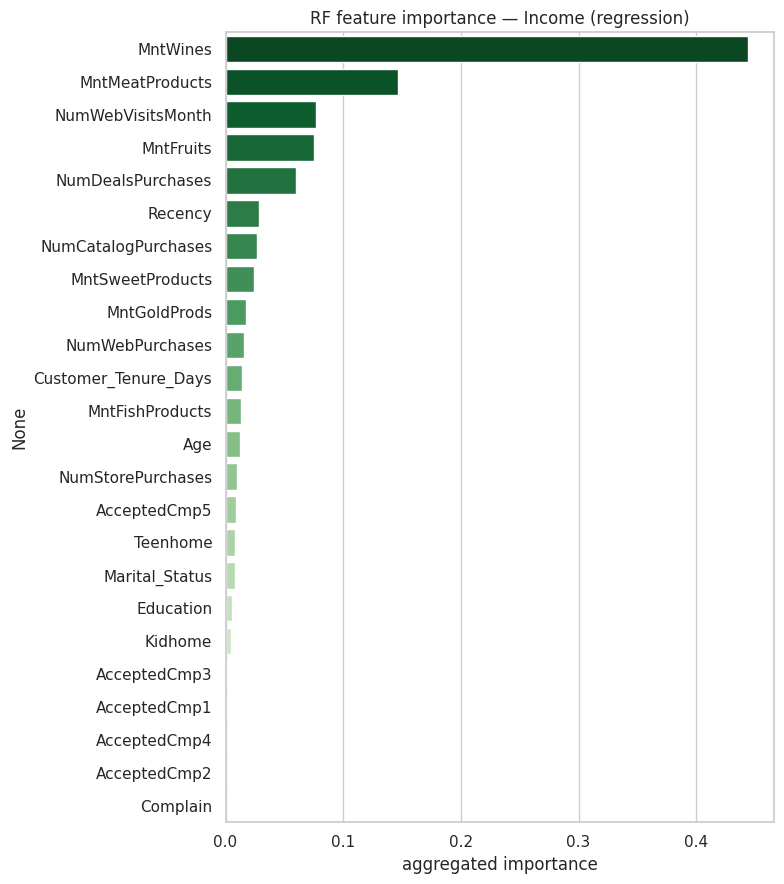

In [32]:
plt.figure(figsize=(8, 9))
sns.barplot(x=importances_reg_agg.values, y=importances_reg_agg.index, hue=importances_reg_agg.index,
            palette="Greens_r", legend=False)
plt.title("RF feature importance — Income (regression)")
plt.xlabel("aggregated importance")
plt.tight_layout()
plt.show()

## Relevance Cross-Check — Mutual Information

In [33]:
from sklearn.feature_selection import mutual_info_regression

mi_numeric = pd.Series(
    mutual_info_regression(X_reg[numeric_cols], df["Income"], discrete_features=False, random_state=42),
    index=numeric_cols,
)

cat_codes = df[categorical_cols].fillna("__missing__").apply(lambda s: pd.factorize(s)[0])
mi_categorical = pd.Series(
    mutual_info_regression(cat_codes, df["Income"], discrete_features=True, random_state=42),
    index=categorical_cols,
)

mi_relevance = pd.concat([mi_numeric, mi_categorical]).sort_values(ascending=False)
mi_relevance_df = mi_relevance.rename("mutual_info").to_frame()
mi_relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in mi_relevance_df.index]
mi_relevance_df

,mutual_info,type
MntMeatProducts,0.722623,numeric
MntWines,0.679187,numeric
NumCatalogPurchases,0.572119,numeric
NumStorePurchases,0.549352,numeric
MntFruits,0.459278,numeric
MntSweetProducts,0.420251,numeric
MntFishProducts,0.407322,numeric
NumWebVisitsMonth,0.396649,numeric
NumWebPurchases,0.348176,numeric
MntGoldProds,0.269003,numeric


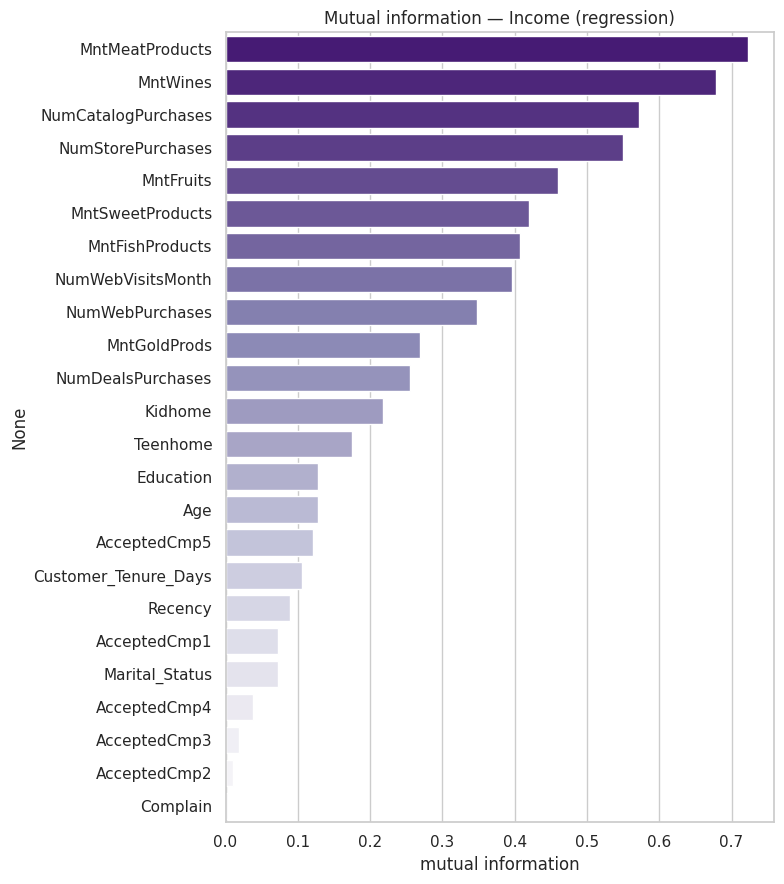

In [34]:
plt.figure(figsize=(8, 9))
sns.barplot(x=mi_relevance.values, y=mi_relevance.index, hue=mi_relevance.index,
            palette="Purples_r", legend=False)
plt.title("Mutual information — Income (regression)")
plt.xlabel("mutual information")
plt.tight_layout()
plt.show()